In [258]:
#Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [259]:
url="https://raw.githubusercontent.com/Smarth02/Laptop-Price-Prediction/refs/heads/main/laptop_data.csv"


In [260]:
#Reading the dataset
df=pd.read_csv(url)

In [261]:
print("First Five rows of the dataset")
df.head()

First Five rows of the dataset


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [262]:
print("Statistical summary of the numerical columns")
df.describe()

Statistical summary of the numerical columns


,Unnamed: 0,Inches,Price
count,1303.00000,1303.000000,1303.000000
mean,651.00000,15.017191,59870.042910
std,376.28801,1.426304,37243.201786
min,0.00000,10.100000,9270.720000
25%,325.50000,14.000000,31914.720000
50%,651.00000,15.600000,52054.560000
75%,976.50000,15.600000,79274.246400
max,1302.00000,18.400000,324954.720000


In [263]:
print("Summary of the dataset")
df.info()

Summary of the dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [264]:
print("Total number of null values")
df.isna().sum().sum()

Total number of null values


np.int64(0)

In [265]:
df['Ram']=df['Ram'].str.replace("GB", "").astype(int) #Convert string to integer
df['Weight']=df['Weight'].str.replace("kg", "").astype(float) #Convert string to float

In [266]:
df.drop('Unnamed: 0', axis=1, inplace=True) #Remove the first column

/tmp/ipykernel_1461/3864544739.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Company', palette='Blues')


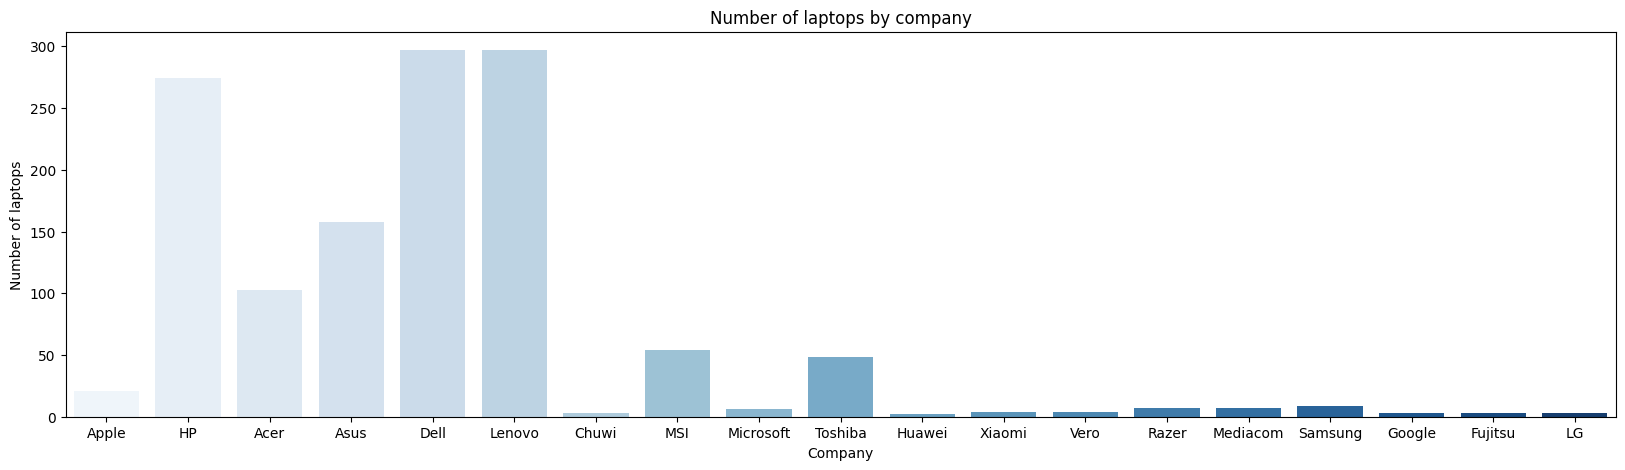

In [267]:
#Number of laptops by company
plt.figure(figsize=(20, 5))
sns.countplot(data=df, x='Company', palette='Blues')
plt.title('Number of laptops by company')
plt.xlabel('Company')
plt.ylabel('Number of laptops')
plt.show()

/tmp/ipykernel_1461/3591489561.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='TypeName', palette='Blues')


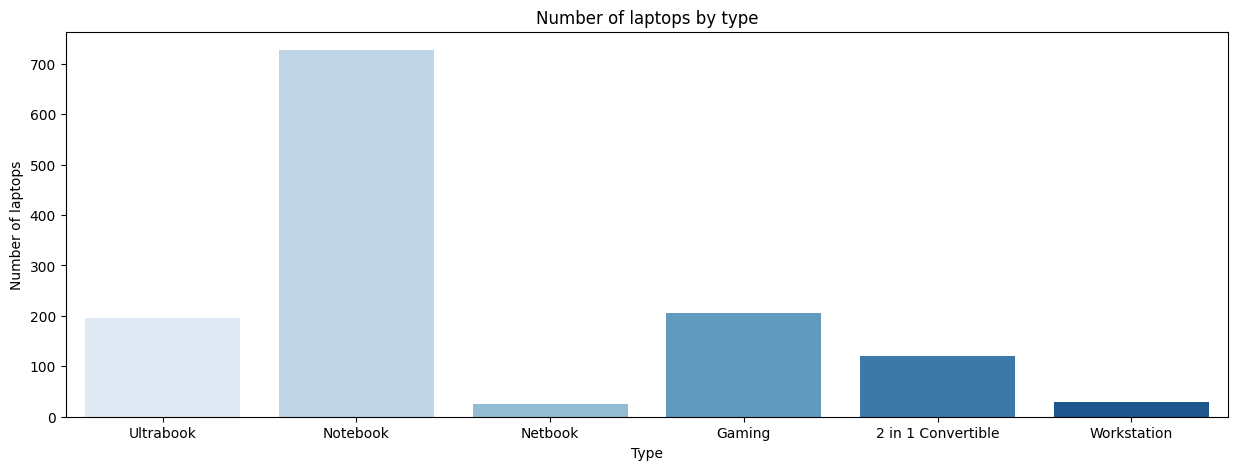

In [268]:
#Number of laptops by type
plt.figure(figsize=(15, 5))
sns.countplot(data=df, x='TypeName', palette='Blues')
plt.title('Number of laptops by type')
plt.xlabel('Type')
plt.ylabel('Number of laptops')
plt.show()

/tmp/ipykernel_1461/3156983981.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Ram', palette='Blues')


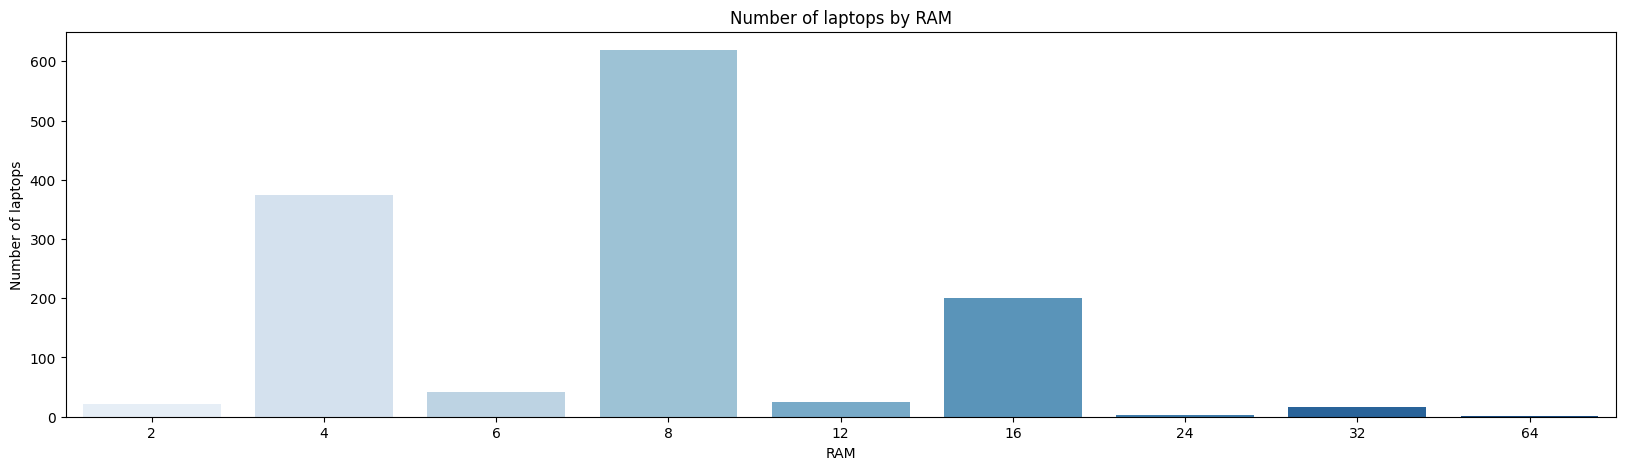

In [269]:
#Number of laptops by RAM
plt.figure(figsize=(20, 5))
sns.countplot(data=df, x='Ram', palette='Blues')
plt.title('Number of laptops by RAM')
plt.xlabel('RAM')
plt.ylabel('Number of laptops')
plt.show()

/tmp/ipykernel_1461/1344313188.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='OpSys', palette='Blues')


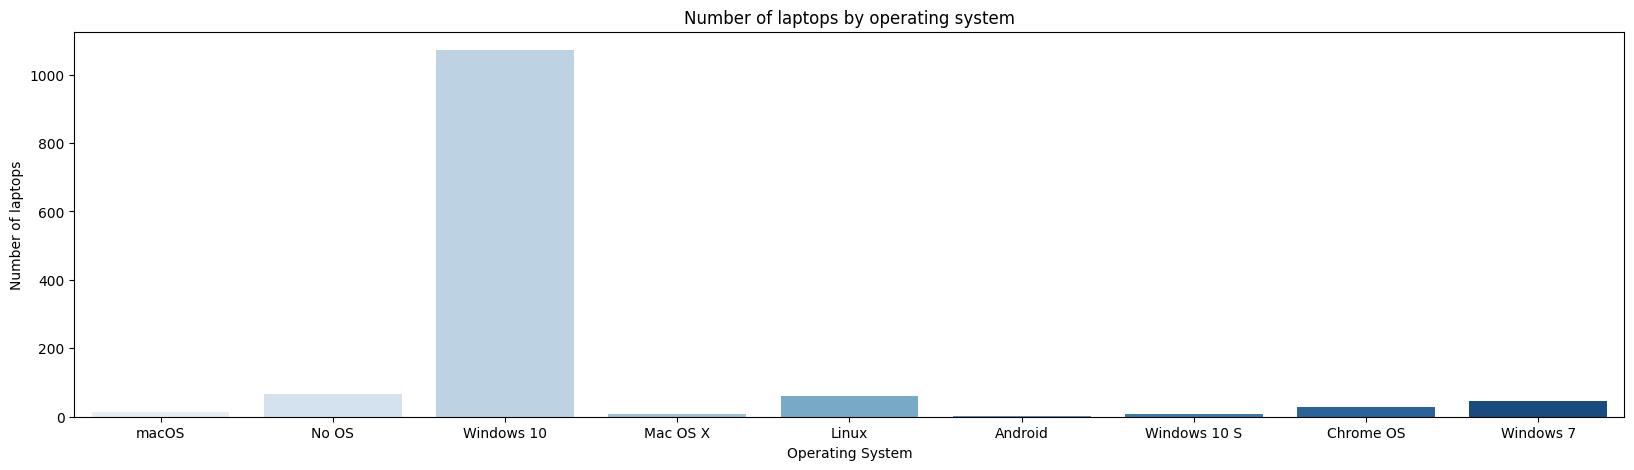

In [270]:
#Number of laptops by Operating System
plt.figure(figsize=(20, 5))
sns.countplot(data=df, x='OpSys', palette='Blues')
plt.title('Number of laptops by operating system')
plt.xlabel('Operating System')
plt.ylabel('Number of laptops')
plt.show()

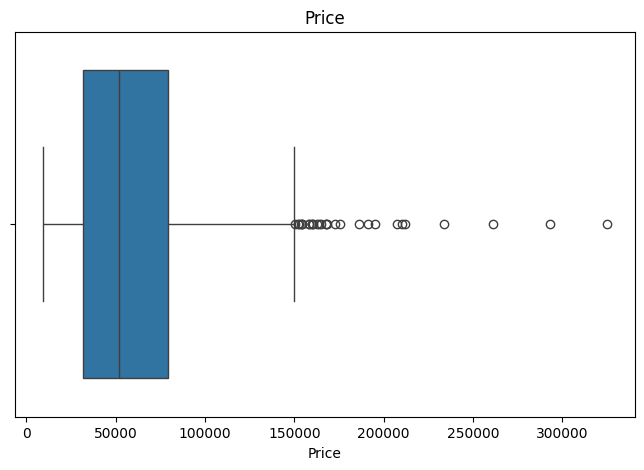

In [271]:
#Box plots to detect outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Price'])
plt.title('Price')
plt.show()

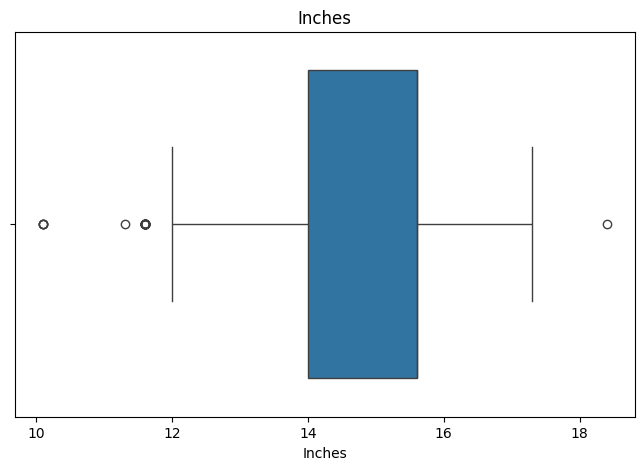

In [272]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Inches'])
plt.title('Inches')
plt.show()

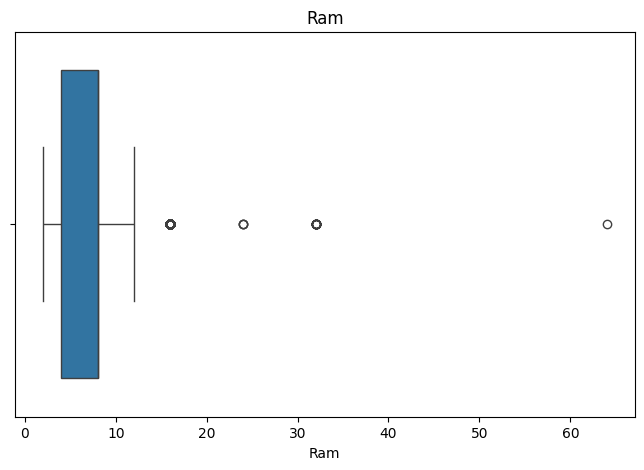

In [273]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Ram'])
plt.title("Ram")
plt.show()

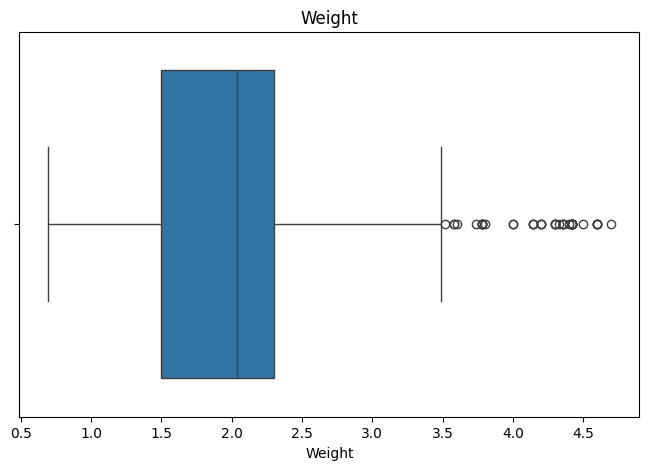

In [274]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Weight'])
plt.title('Weight')
plt.show()

In [275]:
#Remove outliers from all numerical columns using 1.5*IQR method
df_clean=df.copy()
numerical_cols=df_clean.select_dtypes(include=np.number).columns
for col in numerical_cols:
  Q1=df_clean[col].quantile(0.25)
  Q3=df_clean[col].quantile(0.75)
  IQR=Q3-Q1
  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR
  df_clean=df_clean[(df_clean[col]>=lower)&(df_clean[col]<=upper)]

In [276]:
#Checking how much data is removed
print(df.shape)
print(df_clean.shape)

(1303, 11)
(1008, 11)


In [277]:
df=df_clean.copy()

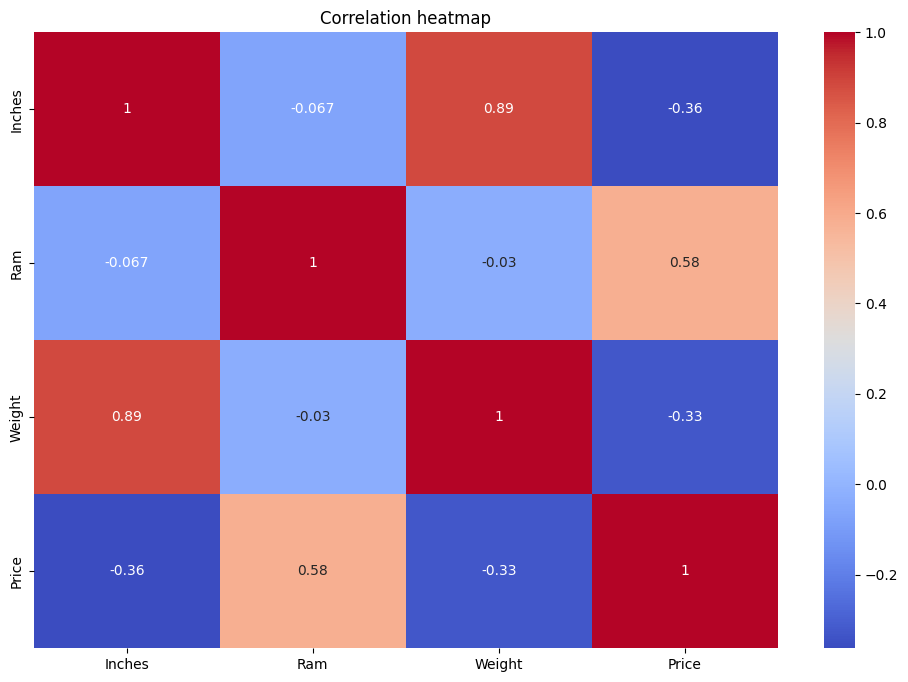

In [278]:
numerical_df=df.select_dtypes(include=np.number)
corr=numerical_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

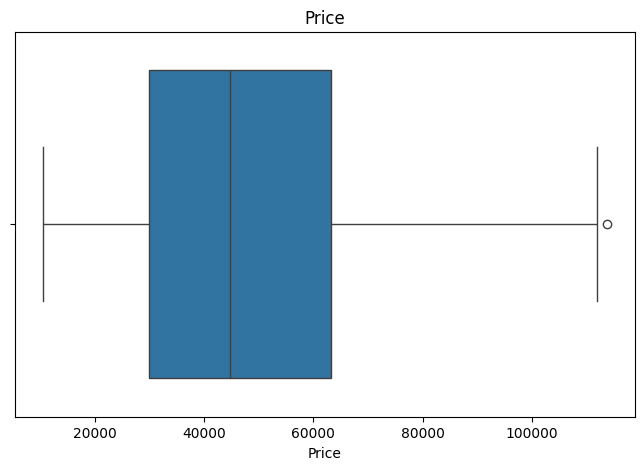

In [279]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Price'])
plt.title('Price')
plt.show()

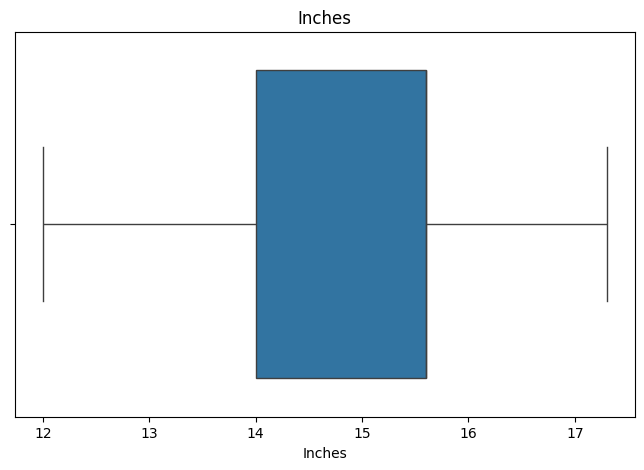

In [280]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Inches'])
plt.title('Inches')
plt.show()

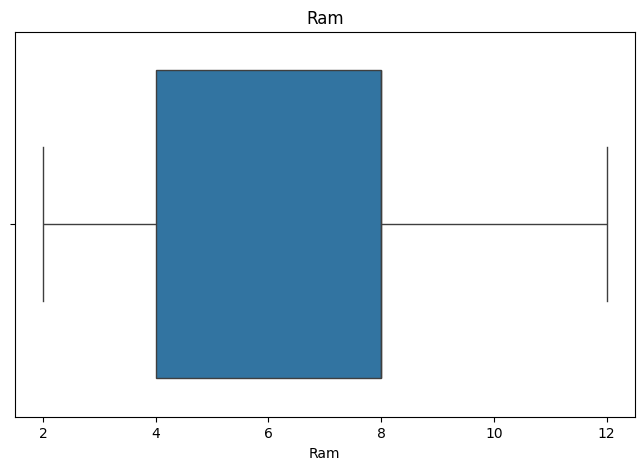

In [281]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Ram'])
plt.title("Ram")
plt.show()

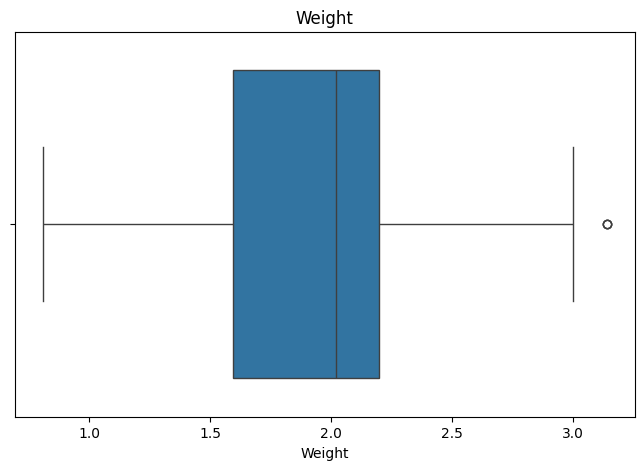

In [282]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Weight'])
plt.title('Weight')
plt.show()

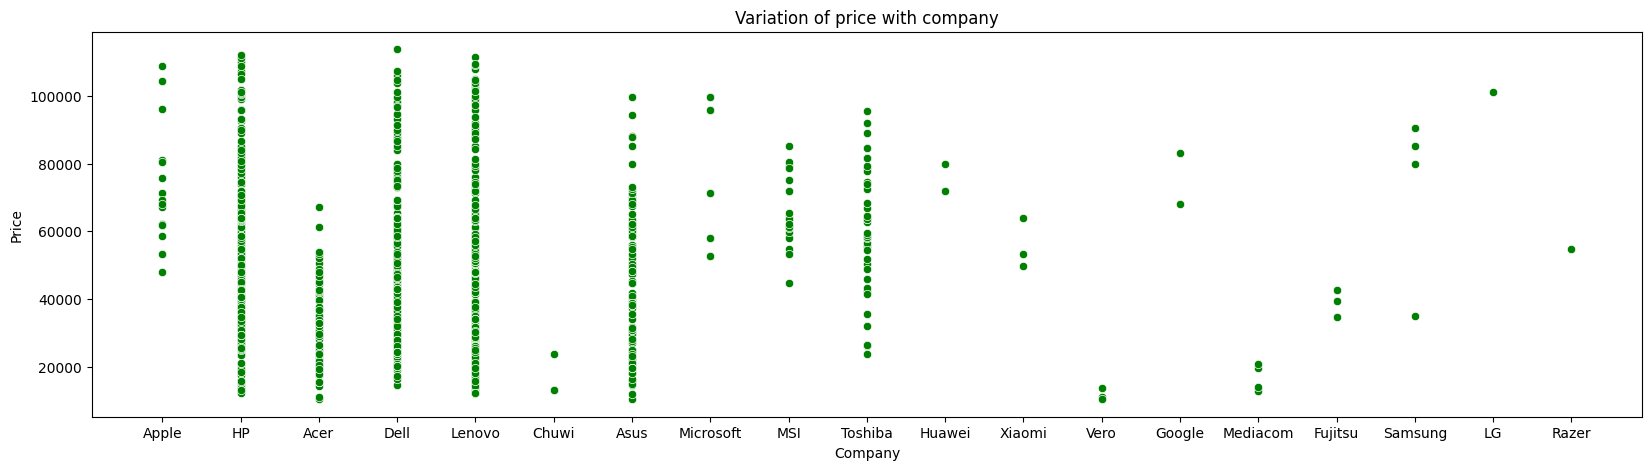

In [283]:
#Variation of price with company
plt.figure(figsize=(20, 5))
sns.scatterplot(x='Company', y='Price', data=df, color='green')
plt.title('Variation of price with company')
plt.xlabel('Company')
plt.ylabel('Price')
plt.show()

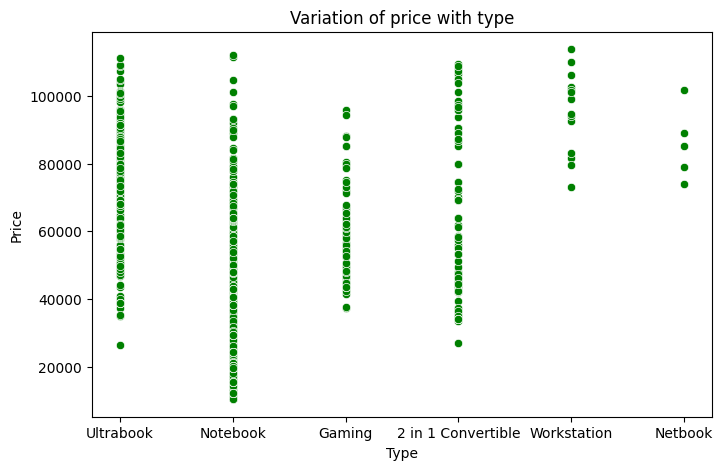

In [284]:
#Variation of price with type
plt.figure(figsize=(8, 5))
sns.scatterplot(x='TypeName', y='Price', data=df, color='green')
plt.title('Variation of price with type')
plt.xlabel('Type')
plt.ylabel('Price')
plt.show()

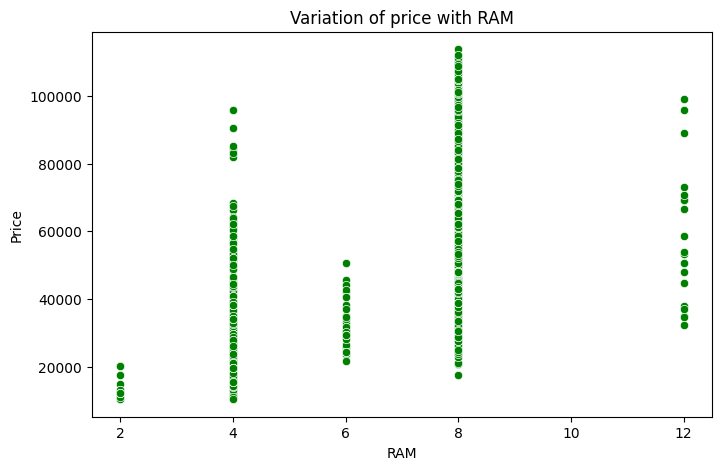

In [285]:
#Variation of price with RAM
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Ram', y='Price', data=df, color='green')
plt.title('Variation of price with RAM')
plt.xlabel('RAM')
plt.ylabel('Price')
plt.show()

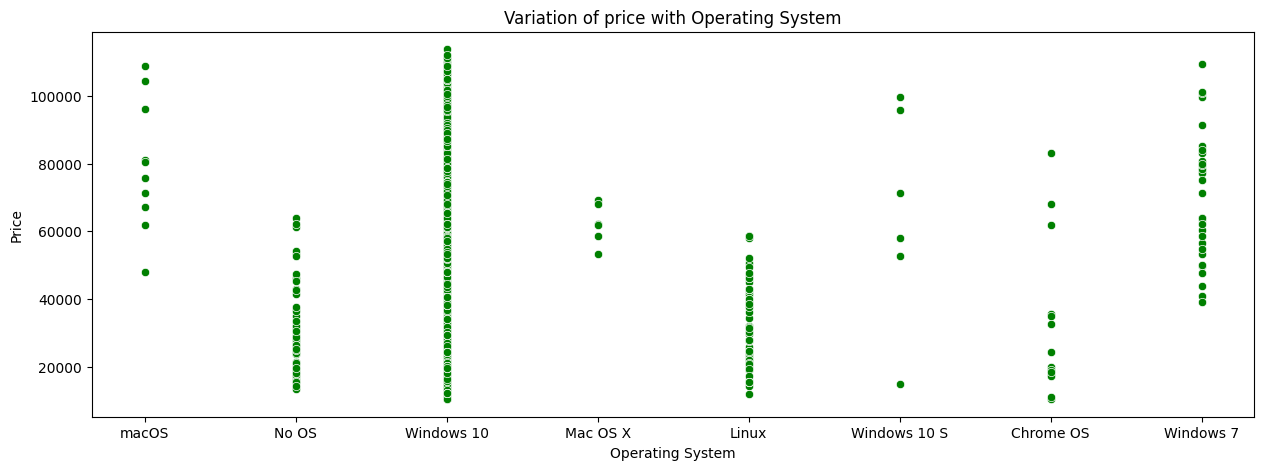

In [286]:
#Variation of price with Operating system
plt.figure(figsize=(15, 5))
sns.scatterplot(x='OpSys', y='Price', data=df, color='green')
plt.title('Variation of price with Operating System')
plt.xlabel('Operating System')
plt.ylabel('Price')
plt.show()

In [287]:
df=pd.get_dummies(df, drop_first=True)

In [288]:
X=df.drop('Price', axis=1) #All columns except price

In [289]:
y=df['Price']

In [290]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [291]:
rf=RandomForestRegressor()

In [292]:
rf.fit(X_train, y_train) #Training

RandomForestRegressor()

In [293]:
y_pred=rf.predict(X_test)

In [294]:
print("Mean absolute error %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 score %.2f" % r2_score(y_test, y_pred))

Mean absolute error 7560.82
Mean squared error 110448433.11
Root mean squared error 10509.44
R2 score 0.81


Using Linear Regression

In [295]:
from sklearn import linear_model

In [296]:
regressor=linear_model.LinearRegression()

In [297]:
regressor.fit(X_train, y_train) #Training

LinearRegression()

In [298]:
y_predicted=regressor.predict(X_test)

In [299]:
print("Mean absolute error %.2f" % mean_absolute_error(y_test, y_predicted))
print("Mean squared error %.2f" % mean_squared_error(y_test, y_predicted))
print("Root mean squared error %.2f" % np.sqrt(mean_squared_error(y_test, y_predicted)))
print("R2 score %.2f" % r2_score(y_test, y_predicted))

Mean absolute error 8998.78
Mean squared error 153202674.68
Root mean squared error 12377.51
R2 score 0.74
